In [3]:
#1.To find number of bookings,sessions,searchesfrom given dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Assign path
Bookings_path="/content/drive/MyDrive/Project /Bookings.csv"
Sessions_path="/content/drive/MyDrive/Project /Sessions.csv"

#Read data
Bookings_Df=pd.read_csv(Bookings_path)
Sessions_Df=pd.read_csv(Sessions_path)


# extracting Distinct bookings and sessions through nunique
D_Bookings=Bookings_Df['booking_id'].nunique()
D_Sessions=Sessions_Df['session_id'].nunique()
D_Searches=Sessions_Df['search_id'].nunique()

print('Distinct bookings are:',D_Bookings)
print('Distinct_Sessions are:' ,D_Sessions)
print('Distinct_Searches are:' ,D_Searches)


Distinct bookings are: 339
Distinct_Sessions are: 331
Distinct_Searches are: 1360


In [4]:
#2.Find how many sessions have >1 booking

#To count the number of Bookings per session
Bookings_per_session=Sessions_Df.groupby('session_id')['booking_id'].nunique()


#session with multiple Bookings
Multiple_Bookings=Bookings_per_session[Bookings_per_session>1]

#To count number of mutiple bookings
number_of_multiple_bookings=Multiple_Bookings.count()
print('Number of sessions with multiple bookings are:',number_of_multiple_bookings)

Number of sessions with multiple bookings are: 10


day_of_week
Thursday     65
Tuesday      59
Monday       51
Friday       51
Saturday     44
Sunday       35
Wednesday    34
Name: count, dtype: int64


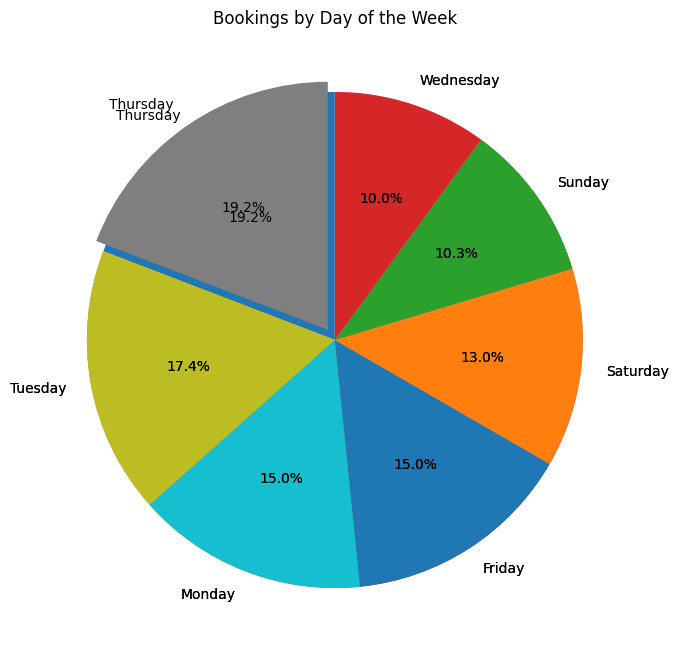

days with highest number of bookings are Thursday=65


In [5]:
#3.Days of the week with highest number of bookings with piechart


# Convert 'booking_time' to datetime objects
Bookings_Df['booking_time'] = pd.to_datetime(Bookings_Df['booking_time'])

# Extract the day of the week
Bookings_Df['day_of_week'] = Bookings_Df['booking_time'].dt.day_name()

# Count bookings for each day of the week
day_counts = Bookings_Df['day_of_week'].value_counts()
print(day_counts)

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Bookings by Day of the Week')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.



# Explode the largest slice for emphasis
explode = [0.05 if day == day_counts.idxmax() else 0 for day in day_counts.index]
plt.pie(day_counts, labels=day_counts.index, explode=explode, autopct='%1.1f%%', startangle=90)


plt.show()

highest_days=day_counts.idxmax()
highest_days_count=day_counts.max()

print(f'days with highest number of bookings are {highest_days}={highest_days_count}')


In [6]:
#4.Total booking and gross booking value by service name

# Group by service name and calculate total bookings and gross booking value
service_statistics = Bookings_Df.groupby('service_name').agg({
    'booking_id': 'count',
    'INR_Amount':'sum'
    }).reset_index()

# Rename columns
service_statistics.columns = ['Service Name', 'Total Bookings', 'Gross Booking Value']

# Print the results
print(service_statistics)



  Service Name  Total Bookings  Gross Booking Value
0      GOIBIBO             186           5897637.97
1          MMT              48            665669.08
2        YATRA             105           3378702.13


In [7]:
#5.Most booked route for Customers >1 booking



# Count bookings per customer
customer_bookings_count = Bookings_Df.groupby('customer_id')['booking_id'].count()

# Filter for customers with more than 1 booking
multiple_bookings_customers = customer_bookings_count[customer_bookings_count > 1].index

# Filter Bookings_Df for customers with more than 1 booking
filtered_bookings = Bookings_Df[Bookings_Df['customer_id'].isin(multiple_bookings_customers)]

# Check if filtered_bookings is empty
if filtered_bookings.empty:
    print("No customers with more than 1 booking found.")
else:
    # Find the most booked route
    most_booked_route = filtered_bookings.groupby(['from_city', 'to_city']).size().idxmax()
    print(f"The most booked route for customers with more than 1 booking is: {most_booked_route}")


The most booked route for customers with more than 1 booking is: ('Gurgaon', 'Roissy-en-France')


In [8]:
#6.Top 3 departure cities for advanced bookings

#filter cities with atleast 5 departures
departure_counts=Bookings_Df['from_city'].value_counts()
min_departures=5
valid_cities=departure_counts[departure_counts>=min_departures].index
advanced_bookings=Bookings_Df[Bookings_Df['from_city'].isin(valid_cities)]

print(departure_counts)

#calculate average days to departure for these cities
average_days_to_departure=advanced_bookings.groupby('from_city')['days_to_departure'].mean()

#sort cities by average days to departure
top_3_cities=average_days_to_departure.sort_values(ascending=False).head(3)
print(top_3_cities)



from_city
Gurgaon               136
Mumbai                 34
Delhi                  29
Devanhalli             24
Rāja Sānsi             17
Chennai                16
Ahmedabad               8
New Delhi               7
Bālāpur                 6
Madhyamgram             6
Thiruvananthapuram      4
Jaipur                  4
Varanasi                4
Hyderabad               4
Kochi                   4
Surat                   4
Pune                    4
Kolkata                 2
Bhubaneswar             2
Bangalore               2
Patna                   2
Chicalim                2
Durlaga                 2
Angamāli                2
Dharamsala              1
Indore                  1
Thrissur                1
Barelā                  1
Hyderābād               1
Gannavaram              1
Jammu                   1
Ranchi                  1
Bikaner                 1
Ferokh                  1
Agartala                1
Lucknow                 1
Mohali                  1
Nagpur                  1
Na

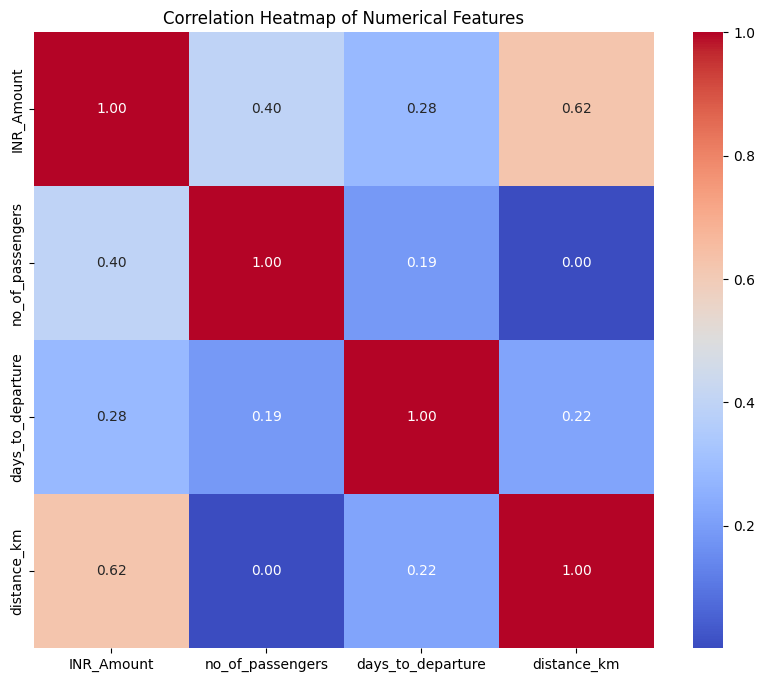

Maximum Correlation (excluding diagonal): 0.6235653096997817
Feature Pair with Maximum Correlation: ('INR_Amount', 'distance_km')
pair with highest correlation between ('INR_Amount', 'distance_km') are 0.6235653096997817 


In [9]:
#7.plot heatmap by displaying correlation


# Select numerical features for correlation analysis
numerical_features = Bookings_Df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()


# Remove diagonal (self-correlation) and stack into a Series
correlation_stack = correlation_matrix.mask(np.equal(*np.indices(correlation_matrix.shape))).unstack()

# Find the maximum correlation and the corresponding feature pair
max_correlation_value = correlation_stack.max()
max_correlation_pair = correlation_stack.idxmax()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


print(f"Maximum Correlation (excluding diagonal): {max_correlation_value}")
print(f"Feature Pair with Maximum Correlation: {max_correlation_pair}")
print(f"pair with highest correlation between {max_correlation_pair} are {max_correlation_value} ")


In [10]:
# 8.Most used device type for bookings on platform

Device_most_used=Bookings_Df.groupby('service_name')['device_type_used'].agg(lambda x: x.mode().iat[0])
print(Device_most_used)


service_name
GOIBIBO        IOS
MMT        Desktop
YATRA      Desktop
Name: device_type_used, dtype: object


Trends in Bookings by Device Type (Quarterly):
    quarter device_type_used  booking_count
0         1          Android             21
1         1          Desktop             49
2         1              IOS             40
3         1        MobileWeb             13
4         2          Android              6
5         2          Desktop             13
6         2              IOS              9
7         2        MobileWeb              1
8         2           Tablet              1
9         3          Android             14
10        3          Desktop             21
11        3              IOS             14
12        3        MobileWeb              4
13        3           Tablet              1
14        4          Android             29
15        4          Desktop             59
16        4              IOS             34
17        4        MobileWeb              9
18        4           Tablet              1


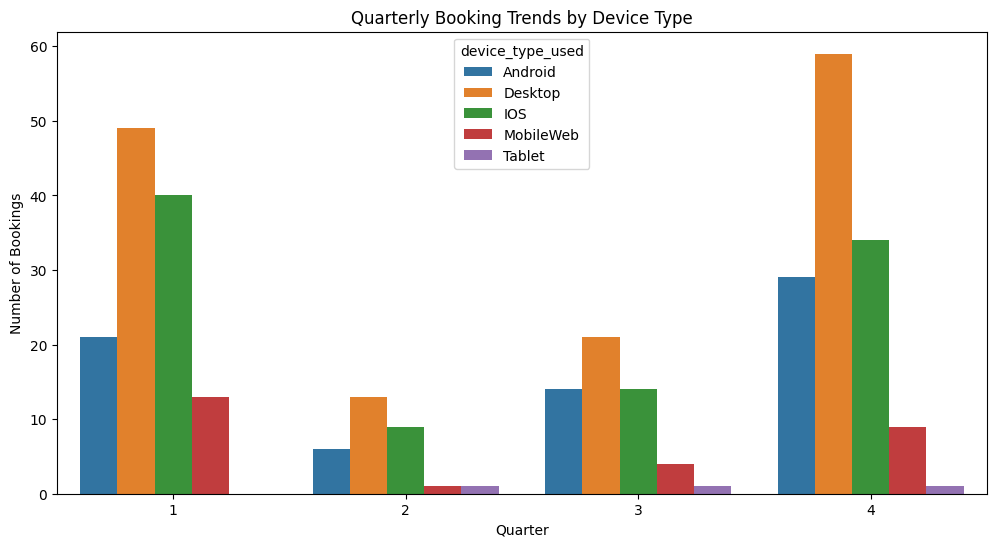

In [11]:
#9.Trends in bookings by device type(quarterly)

# Convert 'booking_time' to datetime objects
Bookings_Df['booking_time'] = pd.to_datetime(Bookings_Df['booking_time'])

# Extract quarter from booking time
Bookings_Df['quarter'] = Bookings_Df['booking_time'].dt.quarter

# Group by quarter and device type, then count bookings
quarterly_device_bookings = Bookings_Df.groupby(['quarter', 'device_type_used'])['booking_id'].count().reset_index()

# Rename the count column
quarterly_device_bookings.rename(columns={'booking_id': 'booking_count'}, inplace=True)

# Print the results
print("Trends in Bookings by Device Type (Quarterly):")
print(quarterly_device_bookings)

# Create a visualization (bar chart)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='quarter', y='booking_count', hue='device_type_used', data=quarterly_device_bookings)
plt.title('Quarterly Booking Trends by Device Type')
plt.xlabel('Quarter')
plt.ylabel('Number of Bookings')
plt.show()



               booking_time
0 2020-02-05 16:12:08+00:00
1 2018-11-21 08:21:47+00:00
2 2019-12-16 22:54:58+00:00
3 2021-10-29 12:25:38+00:00
4 2020-08-11 16:09:10+00:00
                       search_time
0 2020-01-21 21:35:38.910000+00:00
1 2020-01-21 21:37:37.697000+00:00
2 2020-01-21 21:36:11.392000+00:00
3 2020-01-21 21:16:07.685000+00:00
4 2020-01-21 21:34:55.673000+00:00
      index      OBSR
0   2018-09  0.363636
1   2018-10  0.087379
2   2018-11  0.217391
3   2018-12  0.171429
4   2019-01  0.200000
5   2019-06  1.000000
6   2019-07  0.208333
7   2019-08  0.285714
8   2019-09  0.280000
9   2019-10  0.214286
10  2019-11  0.258065
11  2019-12  0.213115
12  2020-01  0.200000
13  2020-02  0.283582
14  2020-03  0.255319
15  2020-05       NaN
16  2020-06       NaN
17  2020-07       NaN
18  2020-08       NaN
19  2020-09       NaN
20  2020-10       NaN
21  2020-11       NaN
22  2020-12       NaN
23  2021-01       NaN
24  2021-02       NaN
25  2021-03       NaN
26  2021-04       NaN
27  20

/tmp/ipython-input-673892643.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  Bookings_Df['booking_year_month'] = Bookings_Df['booking_time'].dt.to_period('M')
/tmp/ipython-input-673892643.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  Sessions_Df['search_year_month'] = Sessions_Df['search_time'].dt.to_period('M')


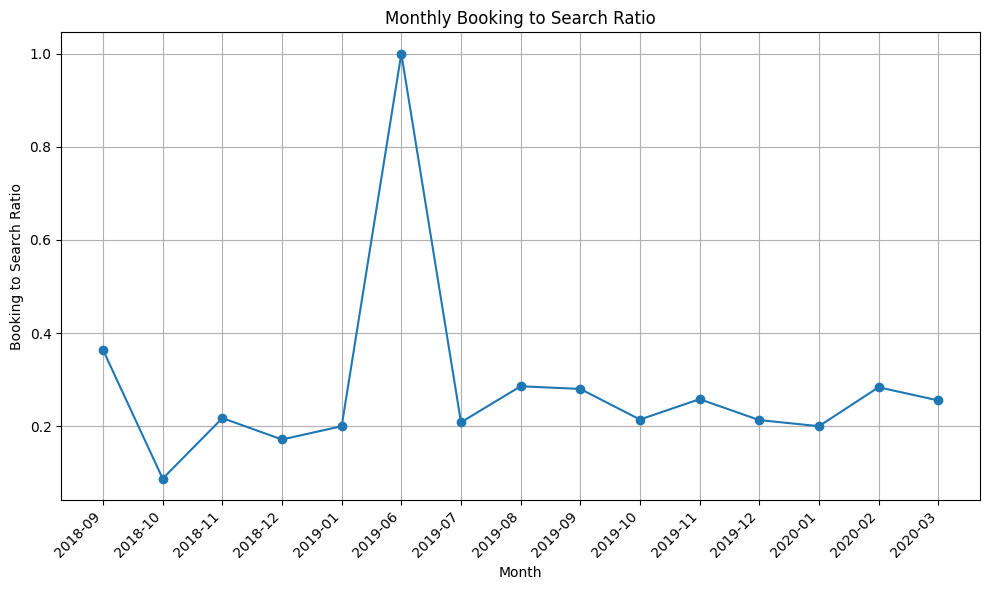

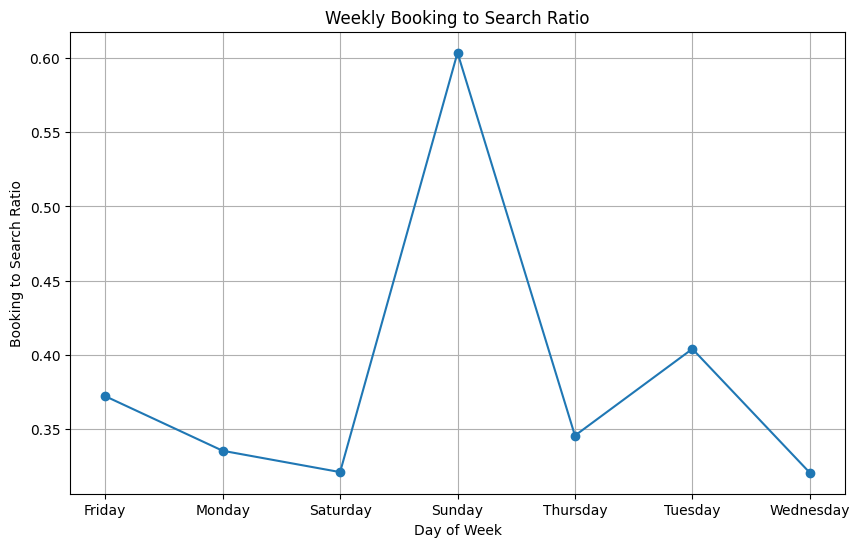

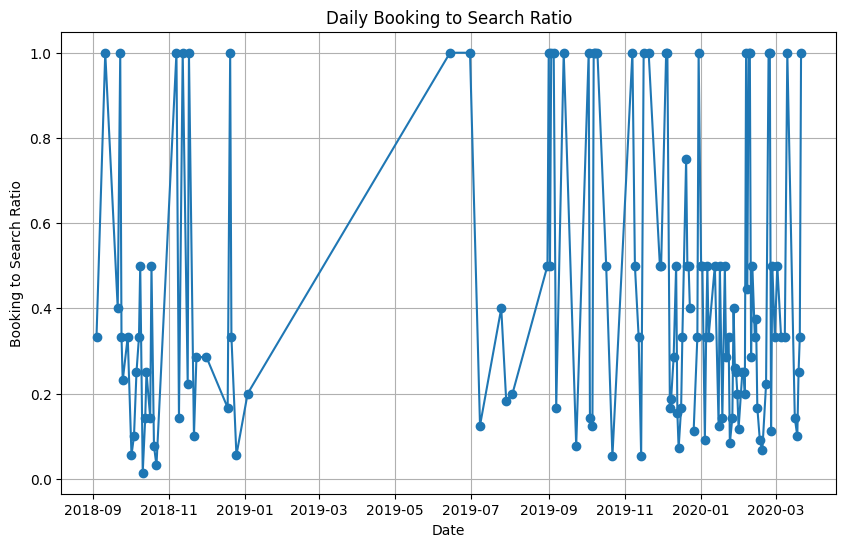

In [12]:
#10.12 customers performed a total of 100searches but only a few of them performed 10 bookings in total

#searches=100
#Bookings=10
#customers=12

#overall booking to search ratio ober=10/100=0.1

#Convert booking time ,search time to dataframe formats
Bookings_Df['booking_time'] = pd.to_datetime(Bookings_Df['booking_time'],errors='coerce')
Sessions_Df['search_time'] = pd.to_datetime(Sessions_Df['search_time'],errors='coerce')

#check date time conversion
print(Bookings_Df[['booking_time']].head())
print(Sessions_Df[['search_time']].head())


#extract year-month and day of week
Bookings_Df['booking_date'] = Bookings_Df['booking_time'].dt.date
Sessions_Df['search_date'] = Sessions_Df['search_time'].dt.date
Bookings_Df['booking_day_of_week'] = Bookings_Df['booking_time'].dt.day_name()
Sessions_Df['search_day_of_week'] = Sessions_Df['search_time'].dt.day_name()
Bookings_Df['booking_year_month'] = Bookings_Df['booking_time'].dt.to_period('M')
Sessions_Df['search_year_month'] = Sessions_Df['search_time'].dt.to_period('M')


#calculate bookings searches permonth
bookings_per_month = Bookings_Df.groupby('booking_year_month').size()
searches_per_month = Sessions_Df.groupby('search_year_month').size()
monthly_obsr=(bookings_per_month/searches_per_month).reset_index(name='OBSR')
print(monthly_obsr)


#check monthly oBSR data
print(monthly_obsr.describe())

#calculate bookings and searches perday of week
bookings_per_day_of_week = Bookings_Df.groupby('booking_day_of_week').size()
searches_per_day_of_week = Sessions_Df.groupby('search_day_of_week').size()
day_of_week_obsr=(bookings_per_day_of_week/searches_per_day_of_week).reset_index(name='OBSR')
print(day_of_week_obsr)

#check weekly OBSR data
print(day_of_week_obsr.describe())

#calculate bookings,searches perdate
bookings_per_date = Bookings_Df.groupby('booking_date').size()
searches_per_date = Sessions_Df.groupby('search_date').size()
date_obsr=(bookings_per_date/searches_per_date).reset_index(name='OBSR')
print(date_obsr)

#check daily OBSR data
print(date_obsr.describe())



#plot monthly oBSR
plt.figure(figsize=(10, 6))
plt.plot(monthly_obsr['index'].astype(str), monthly_obsr['OBSR'], marker='o', linestyle='-') # Changed booking_per_month to index and added astype(str) to the Series
plt.title('Monthly Booking to Search Ratio')
plt.xlabel('Month')
plt.ylabel('Booking to Search Ratio')
plt.grid(True)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()




#plot weekly OBSR
plt.figure(figsize=(10, 6))
plt.plot(day_of_week_obsr['booking_day_of_week'], day_of_week_obsr['OBSR'], marker='o', linestyle='-') # Changed 'search_day_of_week' to 'booking_day_of_week'
plt.title('Weekly Booking to Search Ratio')
plt.xlabel('Day of Week')
plt.ylabel('Booking to Search Ratio')
plt.grid(True)
plt.show()


#plot daily oBSR time series
plt.figure(figsize=(10, 6))
plt.plot(date_obsr['index'], date_obsr['OBSR'], marker='o', linestyle='-') # Changed 'booking_date' to 'index'
plt.title('Daily Booking to Search Ratio')
plt.xlabel('Date')
plt.ylabel('Booking to Search Ratio')
plt.grid(True)
plt.show()

